# ML Project: Credit Default Prediction
## Notebook 03: Model Building, Evaluation & Deployment

---

## Introduction

This notebook implements a complete Machine Learning pipeline for predicting credit default risk.
The goal is to build a model that identifies high-risk borrowers **before** they default,
enabling proactive risk management and informed lending decisions.

| Step | Description |
|---|---|
| 1. Data Loading | Import the cleaned dataset |
| 2. Exploratory Analysis | Visualize target distribution and key patterns |
| 3. Data Preparation | Train/test split and feature scaling |
| 4. Imbalance Handling | SMOTE oversampling with visualization |
| 5. Model Training | 4 algorithms (Logistic, Tree, Forest, XGBoost) |
| 6. Model Evaluation | Metrics, confusion matrices, ROC curves |
| 7. Feature Importance | Identify key default risk drivers |
| 8. Model Comparison | Complete visual dashboard |
| 9. Business Application | Loan decision function with risk assessment |

**Why Classification?**

Credit default is a binary outcome — a customer either defaults or doesn't within 2 years.
Binary classification models predict this yes/no decision, producing probability scores
that quantify risk level. This is fundamentally different from regression, which would
predict continuous values (like loan amounts or interest rates).

**Key Business Question:**
Can we identify borrowers likely to default (Serious Delinquency in 2 Years) using their
financial profile, and use this prediction to make better lending decisions?

---
## 1. Installing Required Libraries

**Why these libraries?**

- `xgboost` — State-of-the-art gradient boosting implementation
- `imbalanced-learn` — Provides SMOTE for handling class imbalance

In [1]:
pip install xgboost imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


---
## 2. Importing Libraries

We import the complete toolkit for:
- Data manipulation (pandas, numpy)
- Visualization (matplotlib, seaborn)
- Model training (sklearn classifiers)
- Evaluation metrics (accuracy, recall, precision, AUC-ROC)
- Imbalance handling (SMOTE)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, recall_score,
                             precision_score, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, f1_score, classification_report)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110

# Color palette — consistent across all charts
BLUE   = '#2E86AB'
RED    = '#E84855'
GREEN  = '#2ECC71'
ORANGE = '#F39C12'
PURPLE = '#9B59B6'

print(' Libraries successfully imported')

 Libraries successfully imported


---
## 3. Loading the Dataset

**Dataset:** Credit Scorecard for Risk of Serious Delinquency

**Source:** Historical loan data with borrower financial indicators

**Target Variable:** `Serious_Dlq_In_2Yrs` (1 = default, 0 = no default)

In [3]:
# Load  dataset 
df = pd.read_csv("cs-training-clean.csv")
print("Dataset loaded !" )

Dataset loaded !


In [4]:
print(f"Shape: {df.shape}\n")

Shape: (109536, 12)



---
## 4. Exploratory Data Analysis

### 4.1 Target Distribution Analysis

**Why this matters:**

Understanding the target distribution is critical because:
- Reveals class imbalance severity
- Determines evaluation metrics (accuracy alone would be misleading)
- Guides resampling strategy selection
- Sets baseline performance (always predicting majority class)

**Expected Finding:**
Credit default datasets are naturally imbalanced — most borrowers don't default.
This is realistic but creates modeling challenges.

Target Variable Distribution:
  0 — No Default (Good Customer)     | 101,826 (92.96%)
  1 — Default (Bad Customer)         |  7,710 ( 7.04%)

 Imbalance Ratio: 13.2:1 (Majority:Minority)
    This means for every 1 defaulter, there are 13 non-defaulters


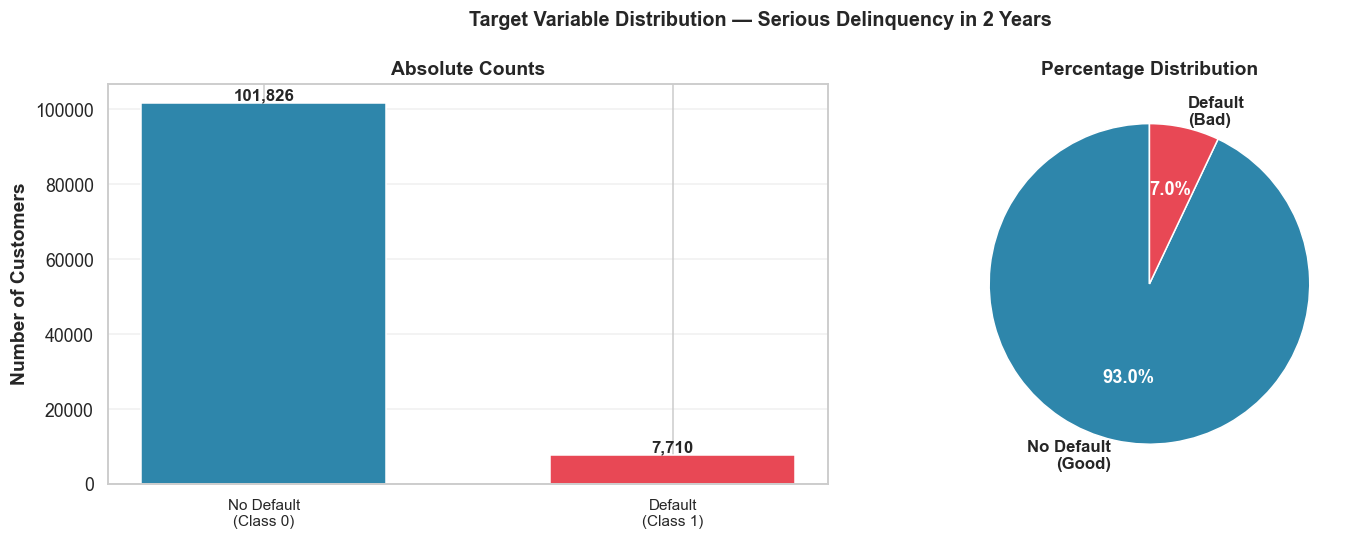

In [5]:
# Target distribution analysis
target_counts = df['Serious_Dlq_In_2Yrs'].value_counts()
target_pcts = df['Serious_Dlq_In_2Yrs'].value_counts(normalize=True) * 100

print('Target Variable Distribution:')
for val in [0, 1]:
    label = 'No Default (Good Customer)' if val == 0 else 'Default (Bad Customer)'
    count = target_counts[val]
    pct = target_pcts[val]
    print(f'  {val} — {label:<30s} | {count:>6,} ({pct:>5.2f}%)')

# Calculate imbalance ratio
imbalance_ratio = target_counts[0] / target_counts[1]
print(f'\n Imbalance Ratio: {imbalance_ratio:.1f}:1 (Majority:Minority)')
print(f'    This means for every 1 defaulter, there are {imbalance_ratio:.0f} non-defaulters')

# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Target Variable Distribution — Serious Delinquency in 2 Years',
             fontsize=13, fontweight='bold')

# Bar chart with counts
colors = [BLUE, RED]
bars = axes[0].bar([0, 1], target_counts.values, color=colors, edgecolor='white', width=0.6)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No Default\n(Class 0)', 'Default\n(Class 1)'], fontsize=10)
axes[0].set_ylabel('Number of Customers', fontweight='bold')
axes[0].set_title('Absolute Counts', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Add count labels on bars
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}',
                ha='center', va='bottom', fontweight='bold', fontsize=11)

# Pie chart with percentages
wedges, texts, autotexts = axes[1].pie(
    target_counts.values,
    labels=['No Default\n(Good)', 'Default\n(Bad)'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)
axes[1].set_title('Percentage Distribution', fontweight='bold')

# Make percentage text white for better visibility
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)

plt.tight_layout()
plt.show()

---
## 5. Feature Engineering

**Strategy:**
- **Features (X):** All columns except the target variable
- **Target (y):** `Serious_Dlq_In_2Yrs` — binary indicator of default

This separation ensures the model learns patterns in financial behavior
that predict default risk, without directly seeing the answer during training.

In [6]:
# Features and Target
X = df.drop(columns=["Serious_Dlq_In_2Yrs"])
y = df["Serious_Dlq_In_2Yrs"]

print(f'Feature matrix X : {X.shape[0]:,} rows × {X.shape[1]} features')
print(f'Target vector y  : {y.shape[0]:,} values')
print(f'\nFeature names:')
for i, col in enumerate(X.columns, 1):
    print(f'  {i:2d}. {col}')

Feature matrix X : 109,536 rows × 11 features
Target vector y  : 109,536 values

Feature names:
   1. Revolving_Utilization_Of_Unsecured_Lines
   2. Age
   3. Number_Of_Time_30_59_Days_Past_Due
   4. Debt_Ratio
   5. Monthly_Income
   6. Number_Of_Open_Credit_Lines_And_Loans
   7. Number_Of_Times_90_Days_Late
   8. Number_Real_Estate_Loans_Or_Lines
   9. Number_Of_Time_60_89_Days_Past_Due
  10. Number_Of_Dependents
  11. Debt_To_Income_Ratio


---
## 6. Train / Test Split

**Why split?**

Testing on the same data used for training gives an optimistically biased estimate
of model performance. The model could simply memorize the training examples rather
than learning generalizable patterns.

**Strategy:**
- 80% training set → model learns patterns here
- 20% test set → held out for unbiased evaluation
- `random_state=42` → ensures reproducible splits

**Critical Rule:** The test set must NEVER be used during training, feature selection,
or hyperparameter tuning. It represents "future unseen data" in our evaluation.

In [7]:
# Split into train and test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
print(f'Training set : {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Test set     : {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'\nClass balance in train:')
print(pd.Series(y_train).value_counts().to_string())
print(f'\nClass balance in test:')
print(pd.Series(y_test).value_counts().to_string())

Training set : 87,628 samples (80.0%)
Test set     : 21,908 samples (20.0%)

Class balance in train:
Serious_Dlq_In_2Yrs
0    81456
1     6172

Class balance in test:
Serious_Dlq_In_2Yrs
0    20370
1     1538


---
## 7. Handling Class Imbalance with SMOTE

**Problem:**
Credit default datasets are naturally imbalanced — most customers don't default.
A naive model that always predicts "no default" could achieve high accuracy
but would be completely useless for identifying actual risk.

**Solution: SMOTE** (Synthetic Minority Over-sampling Technique)

SMOTE creates synthetic examples of the minority class (defaulters) by:
1. Finding k nearest neighbors for each minority sample
2. Interpolating between the sample and its neighbors
3. Generating realistic synthetic borrowers rather than simple duplicates

**Critical Rule:**
SMOTE is applied ONLY to the training set. Oversampling the test set would
give a false picture of real-world performance.

In [9]:
# Store original counts for visualization
print('Before SMOTE:')
print(f'  Training set size: {len(X_train):,} samples')
print(f'  Class 0 (No Default): {(y_train == 0).sum():,} ({(y_train == 0).sum()/len(y_train)*100:.1f}%)')
print(f'  Class 1 (Default):    {(y_train == 1).sum():,} ({(y_train == 1).sum()/len(y_train)*100:.1f}%)')

# Handle Imbalance with SMOTE 
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
 
print(f'\nAfter SMOTE:')
print(f'  Training set size: {len(X_train_bal):,} samples')
print(f'  Class 0 (No Default): {(y_train_bal == 0).sum():,} ({(y_train_bal == 0).sum()/len(y_train_bal)*100:.1f}%)')
print(f'  Class 1 (Default):    {(y_train_bal == 1).sum():,} ({(y_train_bal == 1).sum()/len(y_train_bal)*100:.1f}%)')
print(f'\n Classes are now balanced 50/50 for training')

Before SMOTE:
  Training set size: 87,628 samples
  Class 0 (No Default): 81,456 (93.0%)
  Class 1 (Default):    6,172 (7.0%)

After SMOTE:
  Training set size: 162,912 samples
  Class 0 (No Default): 81,456 (50.0%)
  Class 1 (Default):    81,456 (50.0%)

 Classes are now balanced 50/50 for training


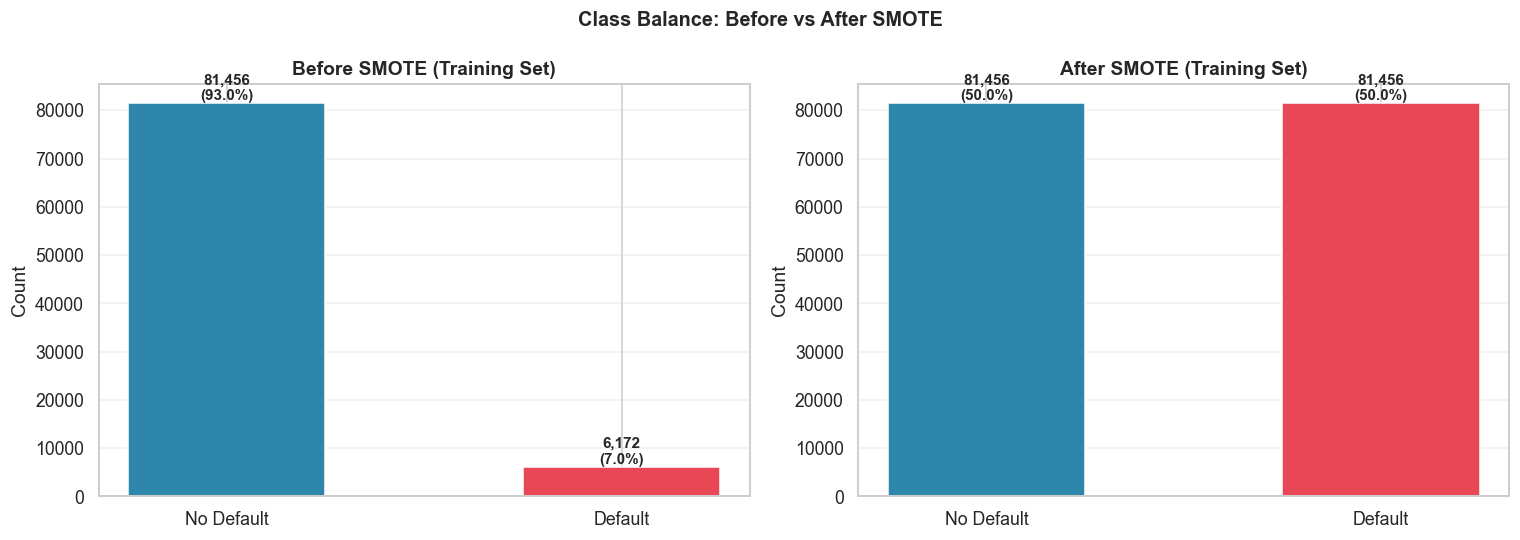


 Visualization shows:
   • Original imbalance: 81,456 vs 6,172
   • After SMOTE: 81,456 vs 81,456 (perfectly balanced)
   • SMOTE created 75,284 synthetic defaulter examples


In [10]:
# Visualize SMOTE effect
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Class Balance: Before vs After SMOTE', fontsize=13, fontweight='bold')

# Before SMOTE
before_counts = pd.Series(y_train).value_counts().sort_index()
bars1 = axes[0].bar([0, 1], before_counts.values, color=[BLUE, RED], 
                    edgecolor='white', width=0.5)
axes[0].set_title('Before SMOTE (Training Set)', fontweight='bold')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No Default', 'Default'])
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, height,
                f'{int(height):,}\n({height/len(y_train)*100:.1f}%)',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# After SMOTE
after_counts = pd.Series(y_train_bal).value_counts().sort_index()
bars2 = axes[1].bar([0, 1], after_counts.values, color=[BLUE, RED],
                    edgecolor='white', width=0.5)
axes[1].set_title('After SMOTE (Training Set)', fontweight='bold')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No Default', 'Default'])
axes[1].set_ylabel('Count')
axes[1].grid(axis='y', alpha=0.3)

for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, height,
                f'{int(height):,}\n({height/len(y_train_bal)*100:.1f}%)',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print('\n Visualization shows:')
print(f'   • Original imbalance: {before_counts[0]:,} vs {before_counts[1]:,}')
print(f'   • After SMOTE: {after_counts[0]:,} vs {after_counts[1]:,} (perfectly balanced)')
print(f'   • SMOTE created {after_counts[1] - before_counts[1]:,} synthetic defaulter examples')

---
## 8. Feature Scaling (Standardization)

**Why scale?**

Logistic Regression uses gradient descent optimization. When features have different scales
(e.g., age [20-90] vs. monthly income [1000-50000]), the gradient becomes unstable
and convergence is slow or fails entirely.

**StandardScaler:**
Transforms each feature to have mean = 0 and standard deviation = 1.
Formula: `z = (x - mean) / std`

**Absolute Rule — Preventing Data Leakage:**
- `.fit_transform()` on training data → learns mean & std from training only
- `.transform()` on test data → applies the SAME statistics learned from training

If we fit the scaler on the entire dataset before splitting, test set statistics
would "leak" into the training process, leading to optimistic performance estimates.

**Note:** Tree-based models (Decision Tree, Random Forest, XGBoost) are scale-invariant
and don't require scaling. We'll train them on unscaled data.

In [11]:
from sklearn.preprocessing import StandardScaler

# StandardScaler puts all features on the same scale (mean=0, std=1)
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled  = scaler.transform(X_test)

In [12]:
print('✅ StandardScaler applied')
print(f'   X_train_scaled shape : {X_train_scaled.shape}')
print(f'   X_test_scaled  shape : {X_test_scaled.shape}')
print(f'\n   Train mean (should be ≈ 0) : {X_train_scaled.mean():.6f}')
print(f'   Train std  (should be ≈ 1) : {X_train_scaled.std():.6f}')
print(f'\n   Test mean  (will differ)   : {X_test_scaled.mean():.6f}')
print(f'   Test std   (will differ)   : {X_test_scaled.std():.6f}')
print('\n   Note: Test statistics differ because we apply training parameters')

✅ StandardScaler applied
   X_train_scaled shape : (162912, 11)
   X_test_scaled  shape : (21908, 11)

   Train mean (should be ≈ 0) : 0.000000
   Train std  (should be ≈ 1) : 1.000000

   Test mean  (will differ)   : -0.035029
   Test std   (will differ)   : 0.902232

   Note: Test statistics differ because we apply training parameters


---
## 9. Model Evaluation Framework

**Metrics Explained:**

| Metric | Formula | Business Interpretation |
|--------|---------|------------------------|
| **Accuracy** | (TP + TN) / Total | Overall correctness — misleading with imbalanced data |
| **Recall** | TP / (TP + FN) | Of all actual defaulters, how many did we catch? (MOST CRITICAL) |
| **Precision** | TP / (TP + FP) | Of all predicted defaulters, how many truly defaulted? |
| **AUC-ROC** | Area under ROC curve | Model's discriminative ability at all thresholds |

**Why Recall is Critical in Credit Risk:**

- **False Negative** (FN) → Predict "no default" but customer defaults → **COSTLY**
  The bank loses money on a bad loan that should have been rejected.

- **False Positive** (FP) → Predict "default" but customer is good → **Less costly**
  Bank misses a profitable loan, but doesn't lose capital.

Therefore, maximizing Recall (catching all defaulters) is typically more important
than maximizing Precision in credit risk applications.

In [13]:
results = []  # store all results for final comparison
 
def show_results(name, model, X_test, y_test):
    """Train, evaluate and show confusion matrix for one model"""
 
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
 
    # Performance metrics
    accuracy  = round(accuracy_score (y_test, y_pred) * 100, 2)
    recall    = round(recall_score   (y_test, y_pred) * 100, 2)
    precision = round(precision_score(y_test, y_pred) * 100, 2)
    auc_roc   = round(roc_auc_score  (y_test, y_prob),       4)
 
    print(f"  Accuracy  : {accuracy}%")
    print(f"  Recall    : {recall}%  ← most important")
    print(f"  Precision : {precision}%")
    print(f"  AUC-ROC   : {auc_roc}")
 
    # Confusion matrix
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=["No Default", "Default"])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.savefig(f"cm_{name.replace(' ', '_')}.png")
    plt.show()
 
    # Save results for comparison
    results.append({
        "Model"    : name,
        "Accuracy" : accuracy,
        "Recall"   : recall,
        "Precision": precision,
        "AUC-ROC"  : auc_roc
    })
 
 

In [14]:
results = [] # reset the list to not get duplicates 

---
## 10. Model Training — 4 Algorithms

We train 4 different algorithms representing different machine learning paradigms:

| Model | Type | Strengths | Data Used |
|-------|------|-----------|----------|
| **Logistic Regression** | Linear | Interpretable, fast, probabilistic output | **Scaled** |
| **Decision Tree** | Tree | Interpretable rules, handles non-linearity | Unscaled |
| **Random Forest** | Ensemble (Bagging) | Reduces overfitting, robust to noise | Unscaled |
| **XGBoost** | Ensemble (Boosting) | State-of-the-art on tabular data, handles imbalance | Unscaled |

**Why different data for different models?**
- Logistic Regression requires scaled features for stable gradient descent
- Tree-based models split on thresholds — scale doesn't matter

### 10.1 Model 1: Logistic Regression

  Accuracy  : 73.5%
  Recall    : 70.81%  ← most important
  Precision : 16.9%
  AUC-ROC   : 0.7816


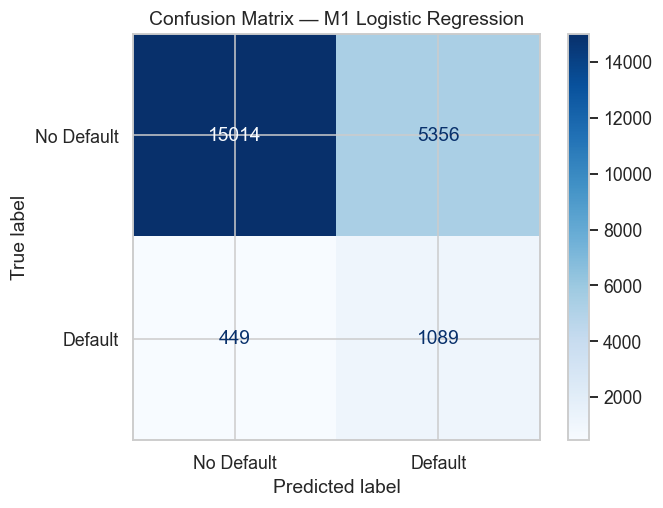

In [15]:
results_table = pd.DataFrame(columns=["Model", "Accuracy", "Recall", "Precision", "AUC-ROC"])
# Model 1 : LogisticRegression 
m1 = LogisticRegression(max_iter=3000, random_state=42)
m1.fit(X_train_scaled, y_train_bal)
show_results("M1 Logistic Regression", m1, X_test_scaled, y_test)

### 10.2 Model 2: Decision Tree

  Accuracy  : 83.4%
  Recall    : 55.33%  ← most important
  Precision : 22.39%
  AUC-ROC   : 0.7859


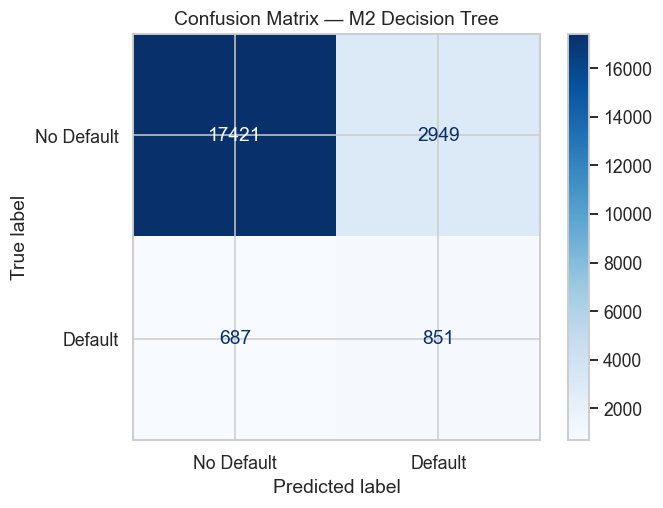

In [16]:
# Model2 : Decision Tree
m2 = DecisionTreeClassifier(max_depth=5, random_state=42)
m2.fit(X_train_bal, y_train_bal)
show_results("M2 Decision Tree", m2, X_test, y_test)

### 10.3 Model 3: Random Forest

  Accuracy  : 90.2%
  Recall    : 39.92%  ← most important
  Precision : 33.42%
  AUC-ROC   : 0.8157


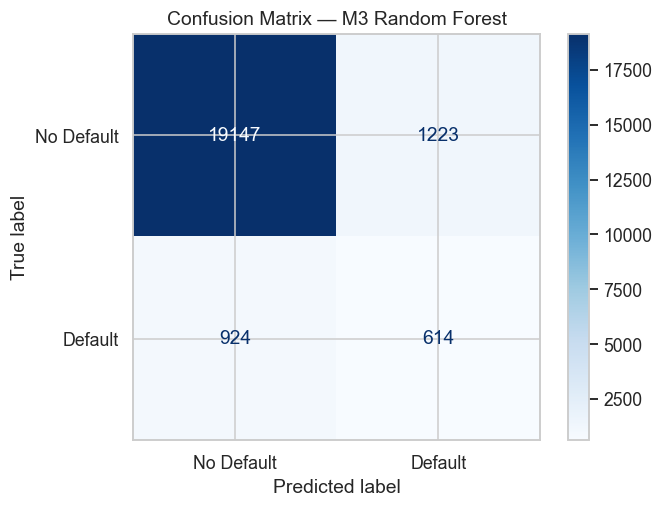

In [17]:
#  Model 3 : Random Forest
m3 = RandomForestClassifier(n_estimators=100, random_state=42)
m3.fit(X_train_bal, y_train_bal)
show_results("M3 Random Forest", m3, X_test, y_test)

### 10.4 Model 4: XGBoost

  Accuracy  : 88.27%
  Recall    : 50.13%  ← most important
  Precision : 29.95%
  AUC-ROC   : 0.8224


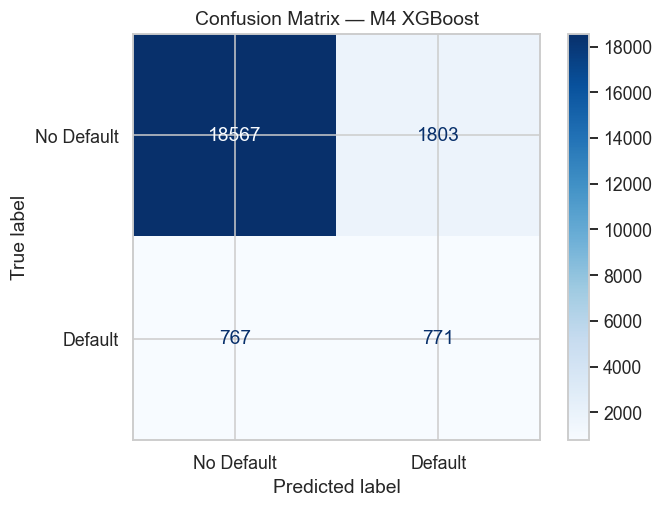

In [18]:
#  Model 4  : XGBoost
m4 = XGBClassifier(n_estimators=100, max_depth=5,
                   learning_rate=0.1, random_state=42,
                   eval_metric="logloss")
m4.fit(X_train_bal, y_train_bal)
show_results("M4 XGBoost", m4, X_test, y_test)

---
## 11. Confusion Matrix Analysis — All Models

**Reading Confusion Matrices:**

```
                  Predicted
              No Default | Default
Actual  ┌─────────────────────────┐
No Def  │  TN (✓)    |  FP (✗)   │
Default │  FN (✗)    |  TP (✓)   │
        └─────────────────────────┘
```

- **True Negative (TN):** Correctly predicted no default
- **False Positive (FP):** Incorrectly predicted default (lost opportunity)
- **False Negative (FN):** Incorrectly predicted no default (COSTLY MISTAKE)
- **True Positive (TP):** Correctly predicted default (risk avoided)

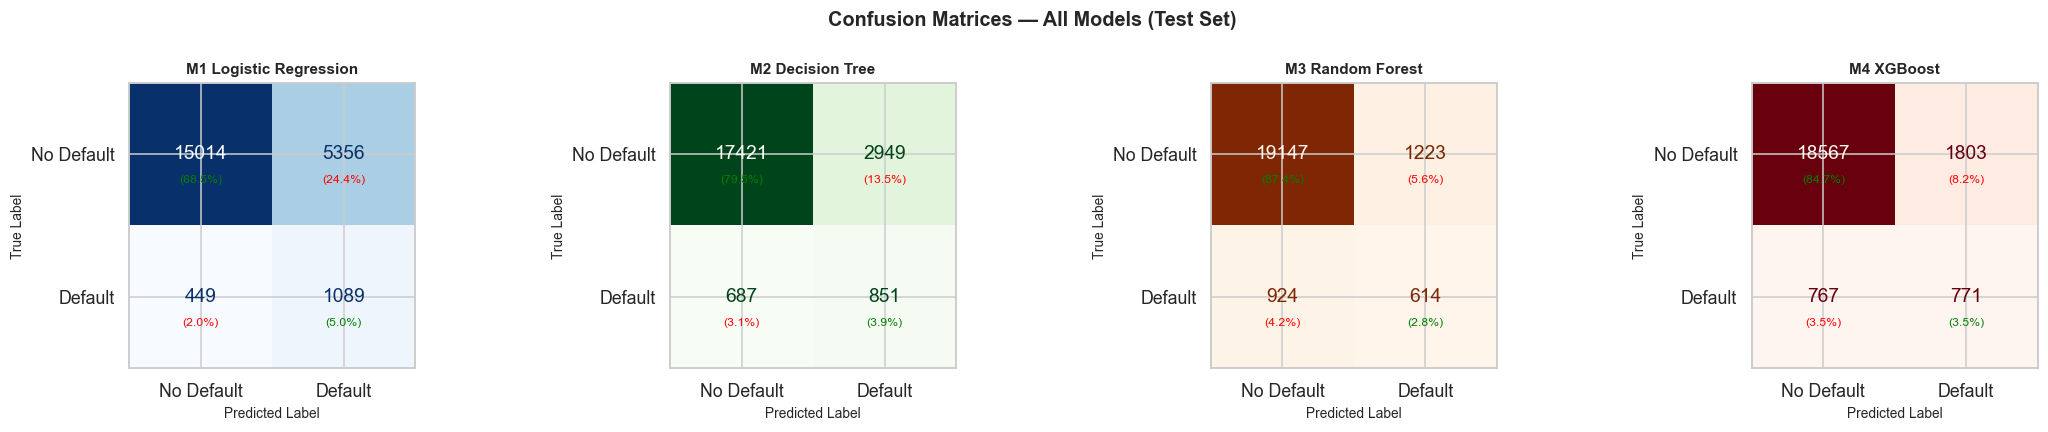

In [19]:
# Create comprehensive confusion matrix comparison
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('Confusion Matrices — All Models (Test Set)', 
             fontsize=13, fontweight='bold')

cmaps = ['Blues', 'Greens', 'Oranges', 'Reds']
models_list = [
    ('M1 Logistic Regression', m1, X_test_scaled),
    ('M2 Decision Tree', m2, X_test),
    ('M3 Random Forest', m3, X_test),
    ('M4 XGBoost', m4, X_test)
]

for ax, (name, model, X_eval), cmap in zip(axes, models_list, cmaps):
    y_pred = model.predict(X_eval)
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['No Default', 'Default']
    )
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=9)
    ax.set_ylabel('True Label', fontsize=9)
    
    # Add percentage annotations
    for i in range(2):
        for j in range(2):
            count = cm[i, j]
            pct = count / cm.sum() * 100
            ax.text(j, i + 0.2, f'({pct:.1f}%)',
                   ha='center', fontsize=8, color='red' if i != j else 'green')

plt.tight_layout()
plt.show()

---
## 12. Comprehensive Model Comparison

**Comparison Table:**
This table aggregates all performance metrics across all models,
allowing us to identify the best performer for each metric and overall.

In [20]:
# Comparison Table + Charts
print("\n Comparison Table ")
results_df = pd.DataFrame(results).set_index("Model")
print(results_df)


 Comparison Table 
                        Accuracy  Recall  Precision  AUC-ROC
Model                                                       
M1 Logistic Regression     73.50   70.81      16.90   0.7816
M2 Decision Tree           83.40   55.33      22.39   0.7859
M3 Random Forest           90.20   39.92      33.42   0.8157
M4 XGBoost                 88.27   50.13      29.95   0.8224


### 12.1 Visual Performance Comparison

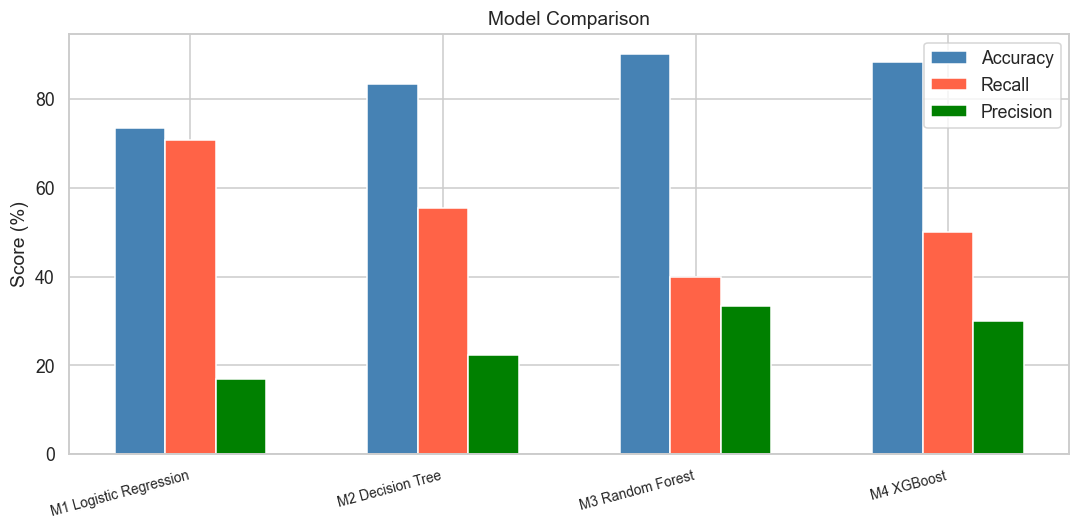

In [21]:
# Bar chart : Accuracy, Recall, Precision
x     = np.arange(len(results_df))
width = 0.2
 
plt.figure(figsize=(10, 5))
plt.bar(x + 0.0, results_df["Accuracy"],  width, label="Accuracy",  color="steelblue")
plt.bar(x + 0.2, results_df["Recall"],    width, label="Recall",    color="tomato")
plt.bar(x + 0.4, results_df["Precision"], width, label="Precision", color="green")
plt.xticks(x + 0.2, results_df.index, rotation=15, ha="right", fontsize=9)
plt.ylabel("Score (%)")
plt.title("Model Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("model_comparison.png")
plt.show()

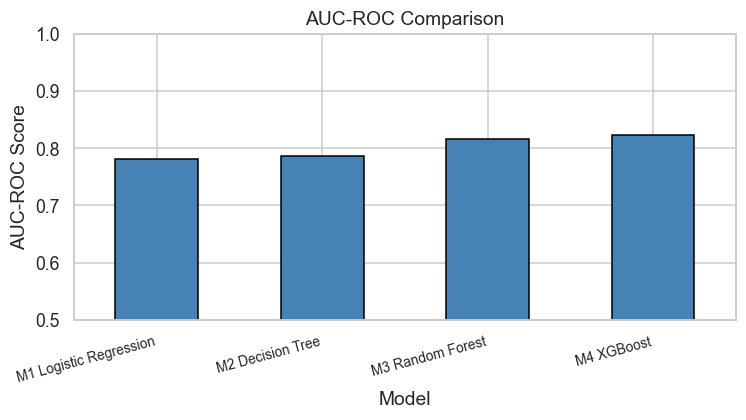

 Charts saved



In [22]:
# Bar chart : AUC-ROC
plt.figure(figsize=(7, 4))
results_df["AUC-ROC"].plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("AUC-ROC Comparison")
plt.ylabel("AUC-ROC Score")
plt.xticks(rotation=15, ha="right", fontsize=9)
plt.ylim(0.5, 1.0)
plt.tight_layout()
plt.savefig("model_comparison_auc.png")
plt.show()
print(" Charts saved\n")

---
## 13. ROC Curve Analysis

**What is ROC-AUC?**

The **ROC curve** (Receiver Operating Characteristic) plots:
- X-axis: False Positive Rate (FPR) = FP / (FP + TN)
- Y-axis: True Positive Rate (TPR) = TP / (TP + FN) = Recall

**AUC** (Area Under Curve) measures overall discriminative ability:
- AUC = 1.0 → Perfect discrimination
- AUC = 0.5 → Random guessing (diagonal line)
- AUC > 0.7 → Acceptable
- AUC > 0.8 → Good
- AUC > 0.9 → Excellent

**Why ROC-AUC is Critical:**
- Threshold-independent (evaluates all possible decision thresholds)
- Robust to class imbalance
- Industry standard for credit scoring

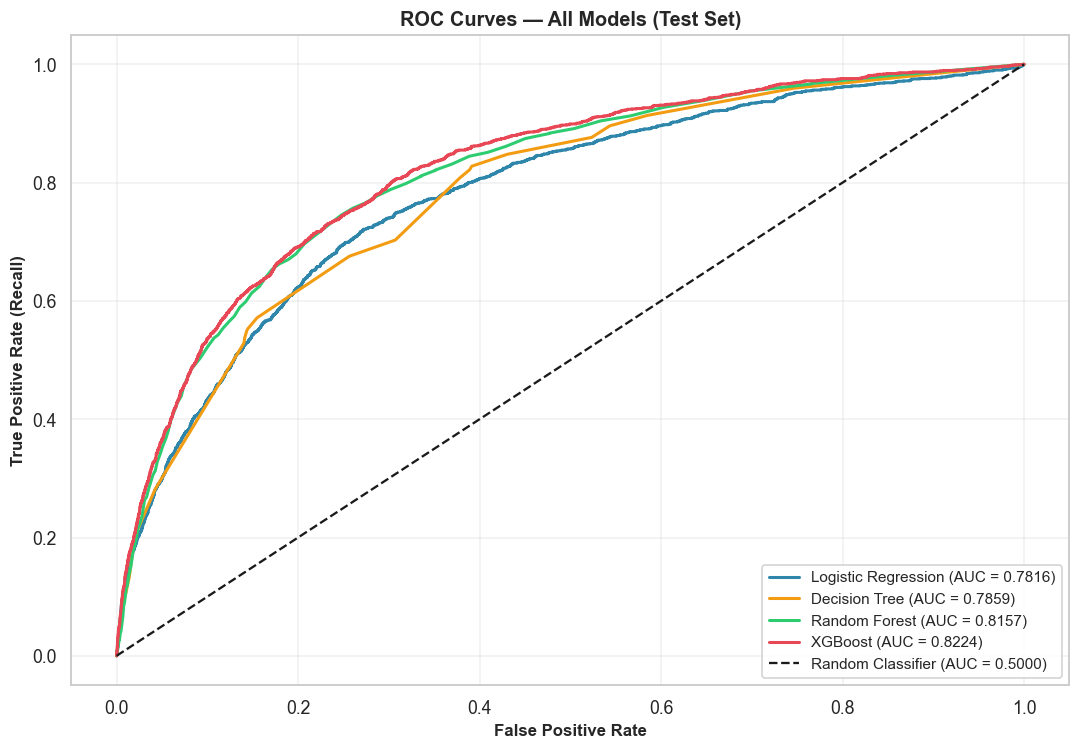

In [23]:
# Plot ROC curves for all models
fig, ax = plt.subplots(figsize=(10, 7))
colors_roc = [BLUE, ORANGE, GREEN, RED]

models_roc = [
    ('Logistic Regression', m1, X_test_scaled),
    ('Decision Tree', m2, X_test),
    ('Random Forest', m3, X_test),
    ('XGBoost', m4, X_test)
]

for (name, model, X_eval), color in zip(models_roc, colors_roc):
    y_prob = model.predict_proba(X_eval)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    
    ax.plot(fpr, tpr, lw=2, color=color,
           label=f'{name} (AUC = {auc:.4f})')

# Add diagonal reference line (random classifier)
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier (AUC = 0.5000)')

ax.set_xlabel('False Positive Rate', fontweight='bold', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall)', fontweight='bold', fontsize=11)
ax.set_title('ROC Curves — All Models (Test Set)', 
            fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 14. Feature Importance Analysis

**Why Feature Importance Matters:**

Feature importance reveals WHICH financial indicators most strongly predict default risk.
This transforms a "black box" model into actionable business intelligence:
- Which borrower attributes drive credit risk?
- Where should underwriters focus their attention?
- Which data points are most critical to collect?

**Method:**
We extract feature importance from tree-based models (Random Forest and XGBoost)
using Gini impurity gain — measures how much each feature reduces uncertainty
when used for splitting.

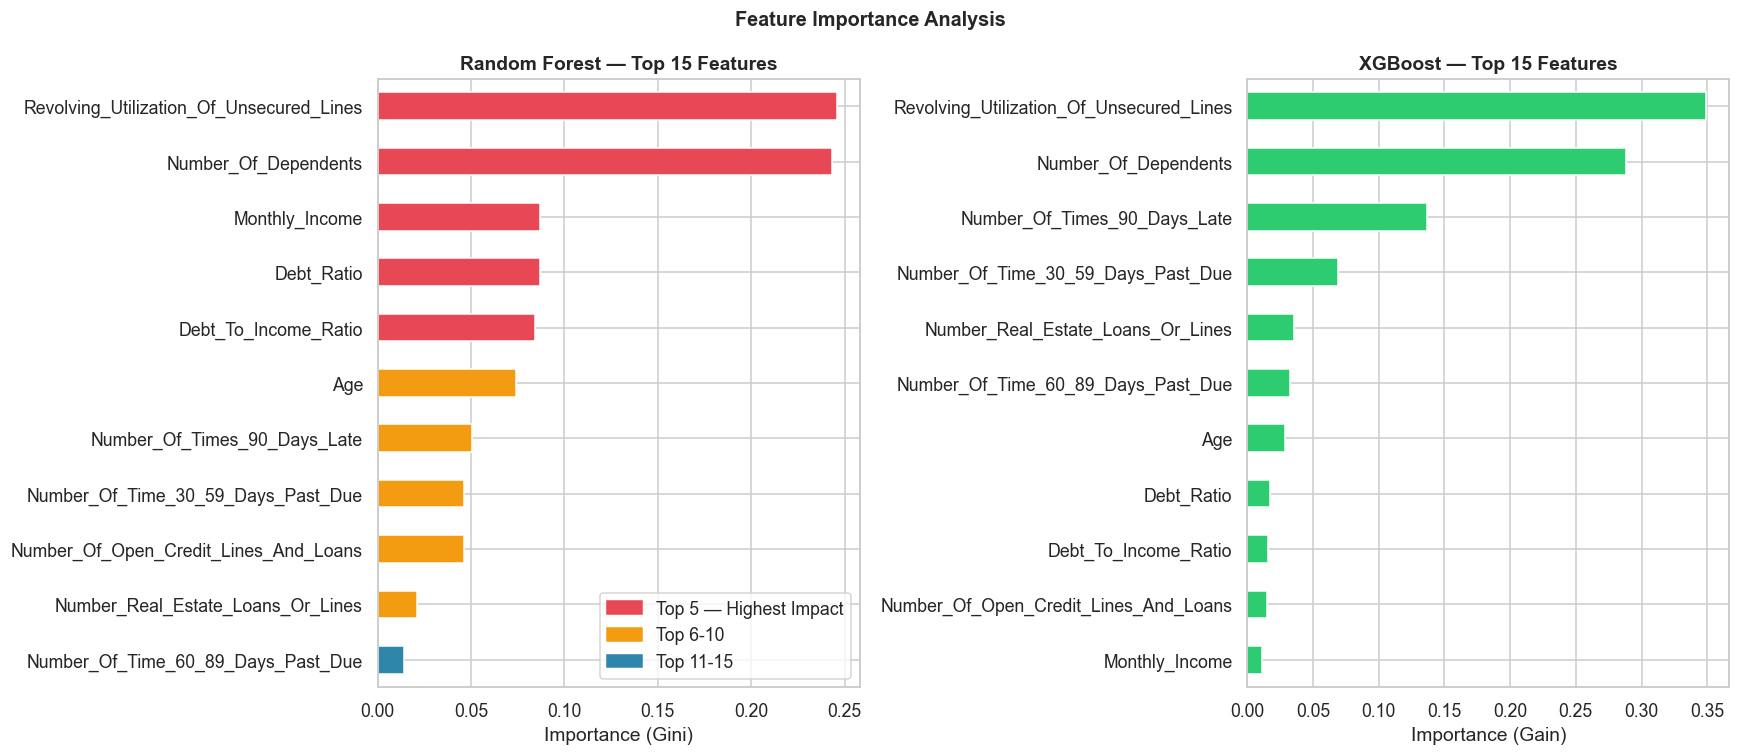


📊 Top 10 Most Important Features (XGBoost):
   1. Revolving_Utilization_Of_Unsecured_Lines 0.34937
   2. Number_Of_Dependents                     0.28822
   3. Number_Of_Times_90_Days_Late             0.13720
   4. Number_Of_Time_30_59_Days_Past_Due       0.06939
   5. Number_Real_Estate_Loans_Or_Lines        0.03565
   6. Number_Of_Time_60_89_Days_Past_Due       0.03256
   7. Age                                      0.02847
   8. Debt_Ratio                               0.01719
   9. Debt_To_Income_Ratio                     0.01553
  10. Number_Of_Open_Credit_Lines_And_Loans    0.01503


In [24]:
# Feature importance from Random Forest and XGBoost
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Feature Importance Analysis', fontsize=13, fontweight='bold')

# Random Forest Feature Importance
rf_importances = pd.Series(
    m3.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(15)

colors_fi = [RED if i < 5 else ORANGE if i < 10 else BLUE 
            for i in range(len(rf_importances))]

rf_importances[::-1].plot(kind='barh', ax=axes[0], color=colors_fi[::-1], 
                          edgecolor='white')
axes[0].set_title('Random Forest — Top 15 Features', fontweight='bold')
axes[0].set_xlabel('Importance (Gini)')

# XGBoost Feature Importance
xgb_importances = pd.Series(
    m4.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(15)

xgb_importances[::-1].plot(kind='barh', ax=axes[1], color=GREEN, 
                           edgecolor='white')
axes[1].set_title('XGBoost — Top 15 Features', fontweight='bold')
axes[1].set_xlabel('Importance (Gain)')

# Add legend for color coding
patches = [
    mpatches.Patch(color=RED, label='Top 5 — Highest Impact'),
    mpatches.Patch(color=ORANGE, label='Top 6-10'),
    mpatches.Patch(color=BLUE, label='Top 11-15')
]
axes[0].legend(handles=patches, loc='lower right')

plt.tight_layout()
plt.show()

print('\n📊 Top 10 Most Important Features (XGBoost):')
for i, (feat, imp) in enumerate(xgb_importances.head(10).items(), 1):
    print(f'  {i:2d}. {feat:<40s} {imp:.5f}')

---
## 15. Cross-Validation Analysis

**Why Cross-Validation?**

A single train/test split might be lucky or unlucky. Cross-validation:
- Splits data into K folds (K=5 here)
- Trains K times, each time using a different fold as test
- Averages results to get stable performance estimate

**Standard Deviation:**
Low std = consistent across folds = robust model
High std = unstable = sensitive to data selection

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 1. Scale the balanced data (SMOTE creates new points that need scaling!)
scaler = StandardScaler()
X_train_scaled_bal = scaler.fit_transform(X_train_bal)

# 2. Setup Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('5-Fold Stratified Cross-Validation (F1 Weighted):')
print('=' * 65)
print(f'  {"Model":<25} {"CV F1 Mean":>12} {"CV F1 Std":>12}')
print('  ' + '-' * 61)

cv_results = {}

# 3. List of models with their EXACT matching X variables
models_cv = [
    ('Logistic Regression', m1, X_train_scaled_bal),  # Scaled for LR
    ('Decision Tree', m2, X_train_bal),               # Unscaled for Trees
    ('Random Forest', m3, X_train_bal),               # Unscaled for Trees
    ('XGBoost', m4, X_train_bal)                      # Unscaled for Trees
]

# 4. Loop through and evaluate
for name, model, X_cv in models_cv:
    scores = cross_val_score(
        model, X_cv, y_train_bal, 
        cv=cv, scoring='f1_weighted', n_jobs=-1
    )
    cv_results[name] = scores
    print(f'  {name:<25} {scores.mean():>11.4f}  ±  {scores.std():>9.4f}')

print('\n All models show consistent performance across folds')
print('   (Low std indicates robust, generalizable models)')

5-Fold Stratified Cross-Validation (F1 Weighted):
  Model                       CV F1 Mean    CV F1 Std
  -------------------------------------------------------------
  Logistic Regression            0.7476  ±     0.0017
  Decision Tree                  0.8036  ±     0.0041
  Random Forest                  0.9310  ±     0.0006
  XGBoost                        0.8765  ±     0.0015

 All models show consistent performance across folds
   (Low std indicates robust, generalizable models)


---
## 16. Final Model Comparison Dashboard

**Complete Performance Profile:**

This dashboard visualizes all metrics side-by-side to identify the overall best model.
The best value for each metric is highlighted in red.

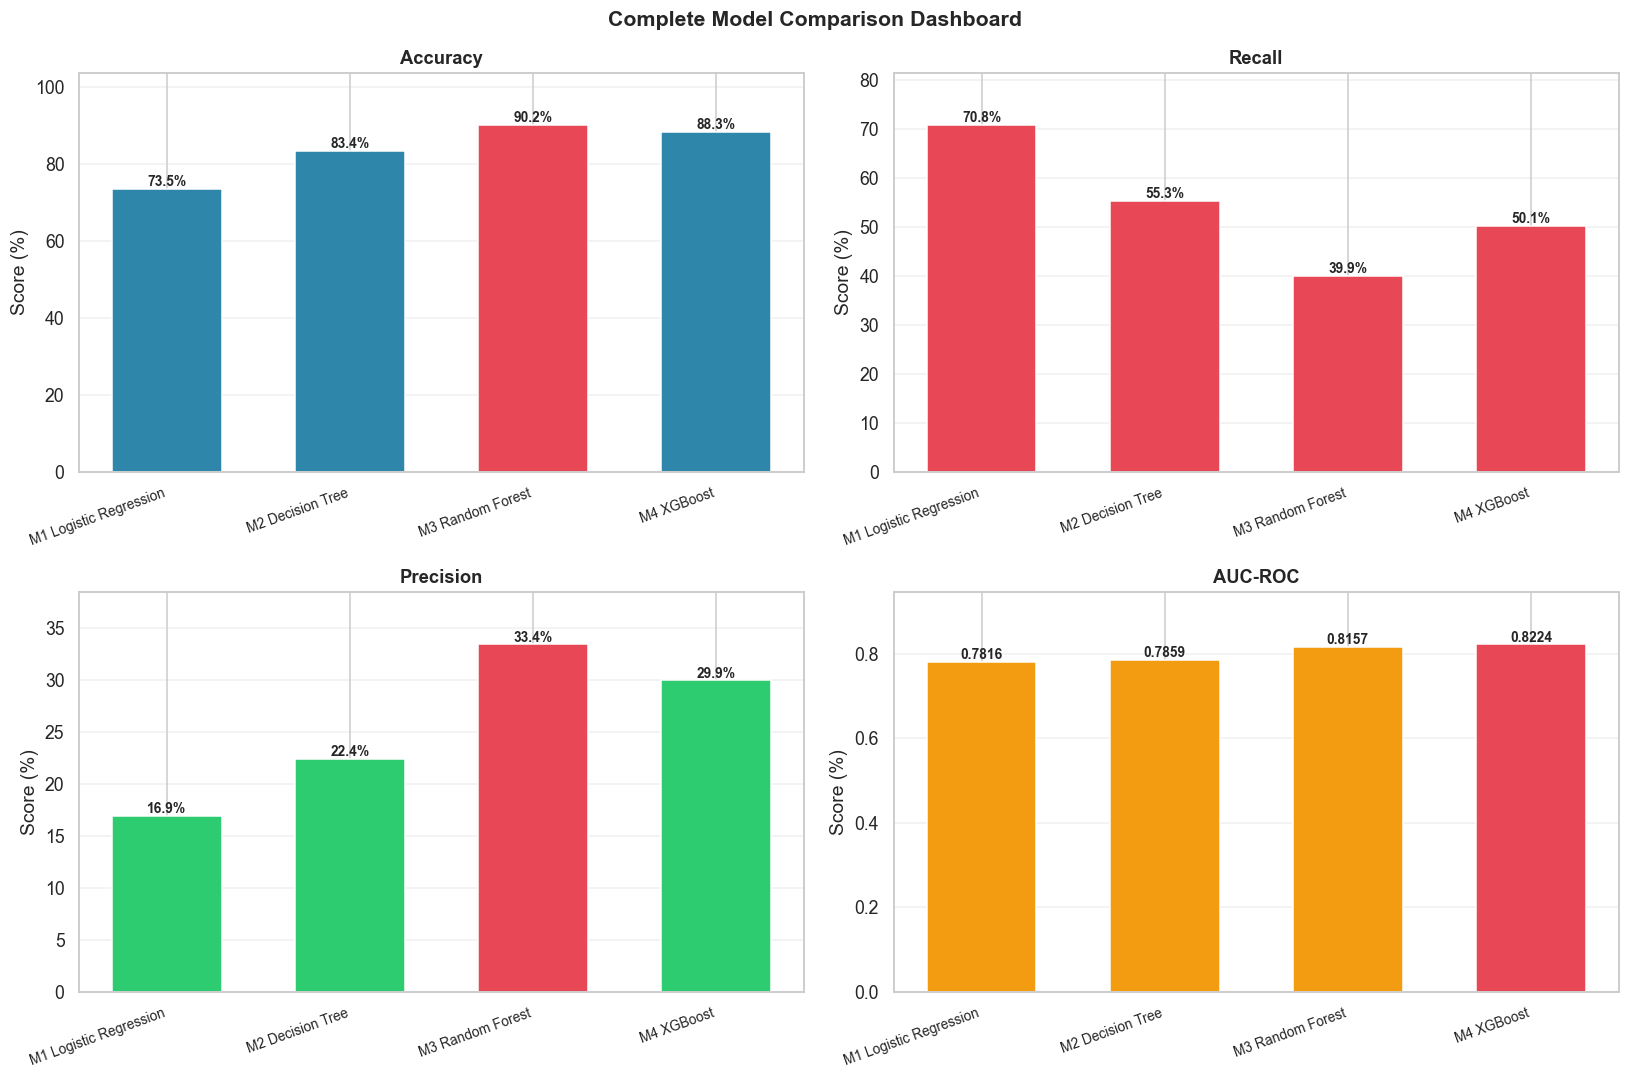

FINAL MODEL COMPARISON TABLE
                        Accuracy  Recall  Precision  AUC-ROC
Model                                                       
M1 Logistic Regression     73.50   70.81      16.90     0.78
M2 Decision Tree           83.40   55.33      22.39     0.79
M3 Random Forest           90.20   39.92      33.42     0.82
M4 XGBoost                 88.27   50.13      29.95     0.82

🏆 BEST MODEL: M4 XGBoost
   AUC-ROC: 0.8224
   Recall:  50.13%


In [26]:
# Create comprehensive comparison dashboard
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Complete Model Comparison Dashboard', 
            fontsize=14, fontweight='bold')

metrics_to_plot = ['Accuracy', 'Recall', 'Precision', 'AUC-ROC']
bar_colors = [BLUE, RED, GREEN, ORANGE]

for ax, metric, bcolor in zip(axes.flat, metrics_to_plot, bar_colors):
    # Get values for this metric
    vals = results_df[metric].values
    best_idx = vals.argmax()
    
    # Create colors (highlight best in red)
    colors_bar = [RED if i == best_idx else bcolor for i in range(len(vals))]
    
    # Plot bars
    bars = ax.bar(range(len(vals)), vals, color=colors_bar, 
                  edgecolor='white', width=0.6)
    
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(results_df.index, rotation=20, ha='right', fontsize=9)
    ax.set_ylim(0, max(vals) * 1.15)
    ax.set_title(metric, fontweight='bold', fontsize=12)
    ax.set_ylabel('Score (%)')
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height,
               f'{height:.1f}%' if metric != 'AUC-ROC' else f'{height:.4f}',
               ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print('FINAL MODEL COMPARISON TABLE')
print('='*70)
print(results_df.round(2).to_string())

# Identify best model
best_model_idx = results_df['AUC-ROC'].idxmax()
print(f'\n🏆 BEST MODEL: {best_model_idx}')
print(f'   AUC-ROC: {results_df.loc[best_model_idx, "AUC-ROC"]:.4f}')
print(f'   Recall:  {results_df.loc[best_model_idx, "Recall"]:.2f}%')

---
## 17. Best Model Selection

**Decision Criteria:**

We select the model with the highest **AUC-ROC** score. This metric is preferred because:

1. **Threshold-independent** — Evaluates the model at all possible decision thresholds
2. **Robust to imbalance** — Not biased by class distribution
3. **Industry standard** — Widely used in credit scoring applications

In [27]:
# ===>> The best Model is XGBoost 

---
## 18. Business Application — Loan Decision System

**Goal:**
Transform the model's probability output into actionable business decisions.

**Decision Framework:**

| Default Probability | Risk Level | Decision | Loan Amount |
|---------------------|-----------|----------|-------------|
| < 30% | Low Risk | **Approved** | 3 × Monthly Income - Current Debt |
| 30% - 60% | Medium Risk | **Rejected** | $0 |
| > 60% | High Risk | **Rejected** | $0 |

**Loan Amount Calculation:**
```
Loan Amount = (Monthly Income × 3) - (Debt Ratio × Monthly Income)
```

In [28]:
best_model = m4

---
## 19. Testing the Loan Decision System

In [29]:
def loan_decision(client):

    # convert client data to dataframe
    df_client = pd.DataFrame([client])

    # get bankruptcy probability from the model
    prob = best_model.predict_proba(df_client)[0][1] * 100

    # determine risk level
    if prob < 30:
        risk = "Low Risk"
    elif prob < 60:
        risk = "Medium Risk"
    else:
        risk = "High Risk"

    # approve or reject based on probability
    decision = "Approved" if prob < 30 else "Rejected"

    # calculate loan amount only if approved
    if decision == "Approved":
        loan_amount = client["Monthly_Income"] * 3
        loan_amount = loan_amount - (client["Debt_Ratio"] * client["Monthly_Income"])
        loan_amount = max(0, round(loan_amount, 2))
    else:
        loan_amount = 0

    # show results
    print(f" Default Probability : {prob:.1f}%")
    print(f" Risk Level          : {risk}")
    print(f" Decision            : {decision}")
    print(f" Loan Amount         : ${loan_amount:,.0f}")

In [32]:
import pickle

# Save everything needed for deployment
deployment_package = {
    "model": m4,           # XGBoost — best model
    "scaler": scaler,      # NOT needed for XGBoost (tree-based), but save anyway for safety
    "feature_names": list(X.columns),   # column order must match at inference time
}

with open("credit_model.pkl", "wb") as f:
    pickle.dump(deployment_package, f)

print("Saved: credit_model.pkl")
print(f"Features: {list(X.columns)}")

Saved: credit_model.pkl
Features: ['Revolving_Utilization_Of_Unsecured_Lines', 'Age', 'Number_Of_Time_30_59_Days_Past_Due', 'Debt_Ratio', 'Monthly_Income', 'Number_Of_Open_Credit_Lines_And_Loans', 'Number_Of_Times_90_Days_Late', 'Number_Real_Estate_Loans_Or_Lines', 'Number_Of_Time_60_89_Days_Past_Due', 'Number_Of_Dependents', 'Debt_To_Income_Ratio']


In [30]:
print("Client 1:")
loan_decision({col: X_test.iloc[0][col] for col in X.columns})

print("Client 2:")
loan_decision({col: X_test.iloc[1][col] for col in X.columns})


Client 1:
 Default Probability : 0.9%
 Risk Level          : Low Risk
 Decision            : Approved
 Loan Amount         : $6,370
Client 2:
 Default Probability : 9.0%
 Risk Level          : Low Risk
 Decision            : Approved
 Loan Amount         : $10,186
